# Quantify junction diversity
## Within junction distance
Create distance matrix between isolates based on pangraph of one junction. Consider the following distances:
- jaccard index of shared sequence length
- jaccard index of shared blogs (problem: don't take into account long deletions that could just have been one event)
- jaccard index of shared edges (problem: sequences might have shared blogs but completely different edges)
- number of divergence points in paths, solve by getting longest common subsequence (Needleman-Wunsch) (doesn't consider movement of blogs)


In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import altair as alt
import numpy as np
import pypangraph as pp
from Bio import Phylo, SeqIO, pairwise2
from Bio import Align

from junction_analysis.diversity_metrics import compare_sequences_by_shared_proportion, calculate_block_ji_matrix, calculate_edge_ji_matrix, calculate_divergence_matrix
from junction_analysis.plotting import plot_heatmap_hover

/opt/homebrew/Caskroom/miniforge/base/envs/junctions/lib/python3.13/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [8]:
_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

,edge,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,max_length,mean_length,n_all_cores,core_left_length,core_right_length,transitive,nonempty_acc_len,nonempty_freq,pangenome_len
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18177,18954,18190.108108,218,16280.0,1699.0,False,727.5,0.018018,1684.0
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11740,12517,11743.500000,221,1530.0,10210.0,False,777.0,0.004505,768.0
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,28035,29472,28041.472973,221,23758.0,4277.0,False,1437.0,0.004505,1433.0
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7366,8143,7373.000000,220,2781.0,4585.0,False,777.0,0.009009,768.0
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10058,48233,10229.959459,221,7295.0,2763.0,False,38175.0,0.004505,37225.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,GPXHVRRZLC_f__KYQOKYBCOW_f,2,12,False,2,1,True,0.693147,18,65788,105315,85551.500000,0,18606.0,29024.0,False,34255.5,1.000000,100857.0
544,EOBHADSLFU_f__SKPHAXSFLS_r,2,1,False,1,2,False,0.000000,1,7231,7231,7231.000000,2,7231.0,7231.0,True,NaN,0.000000,3298.0
545,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83630,83630,83630.000000,2,31644.0,48921.0,False,NaN,0.000000,73408.0
546,YUOECYBHUS_f__ZTHKZYHPIX_f,2,20,True,2,1,True,0.693147,35,66710,186048,126379.000000,0,60232.0,5710.0,False,60437.0,1.000000,160404.0


In [9]:
#example_junction = jdf.iloc[0].edge
#example_junction = "ATPWUNKKID_f__KKPYPKGMXA_f"
example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")
example_pangraph.to_blockstats_df()

,count,n_strains,duplicated,core,len
block_id,,,,,
185719230501067033,4,4,False,False,4204
517157241956952768,7,7,False,False,1248
693804415432571803,170,170,False,False,4736
913783977968963568,168,168,False,False,133
964531385716605116,13,13,False,False,1239
1314867519434933921,169,169,False,False,1920
1708810210093552769,221,221,False,False,2589
2278011600046483881,1,1,False,False,37622
3035246746052306249,169,169,False,False,7212


### Shared sequence length

In [10]:
sequence_comparison_df = example_pangraph.pairwise_accessory_genome_comparison()
jaccard_sequences_df, diff, shared = compare_sequences_by_shared_proportion(sequence_comparison_df, order = "hierarchical")
plot_heatmap_hover(jaccard_sequences_df, diff, shared, show_tick_labels=False, similarity_measure="shared_proportion")

### Shared blocks

In [11]:
jaccard_blocks_df, diff, shared = calculate_block_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_blocks_df, diff, shared, show_tick_labels=False, similarity_measure="shared_blocks")

### Shared edges

In [12]:
jaccard_edges_df, diff, shared = calculate_edge_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_edges_df, diff, shared, show_tick_labels=False, similarity_measure="shared_edges")

### Number of divergence points betwenn paths

In [13]:
divergence_points_mat = calculate_divergence_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(divergence_points_mat, show_tick_labels=False, similarity_measure="divergence_points")

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analyis/helpers.py:5: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



## Metric comparison
Scatter plots comparing the difference metrices with each other

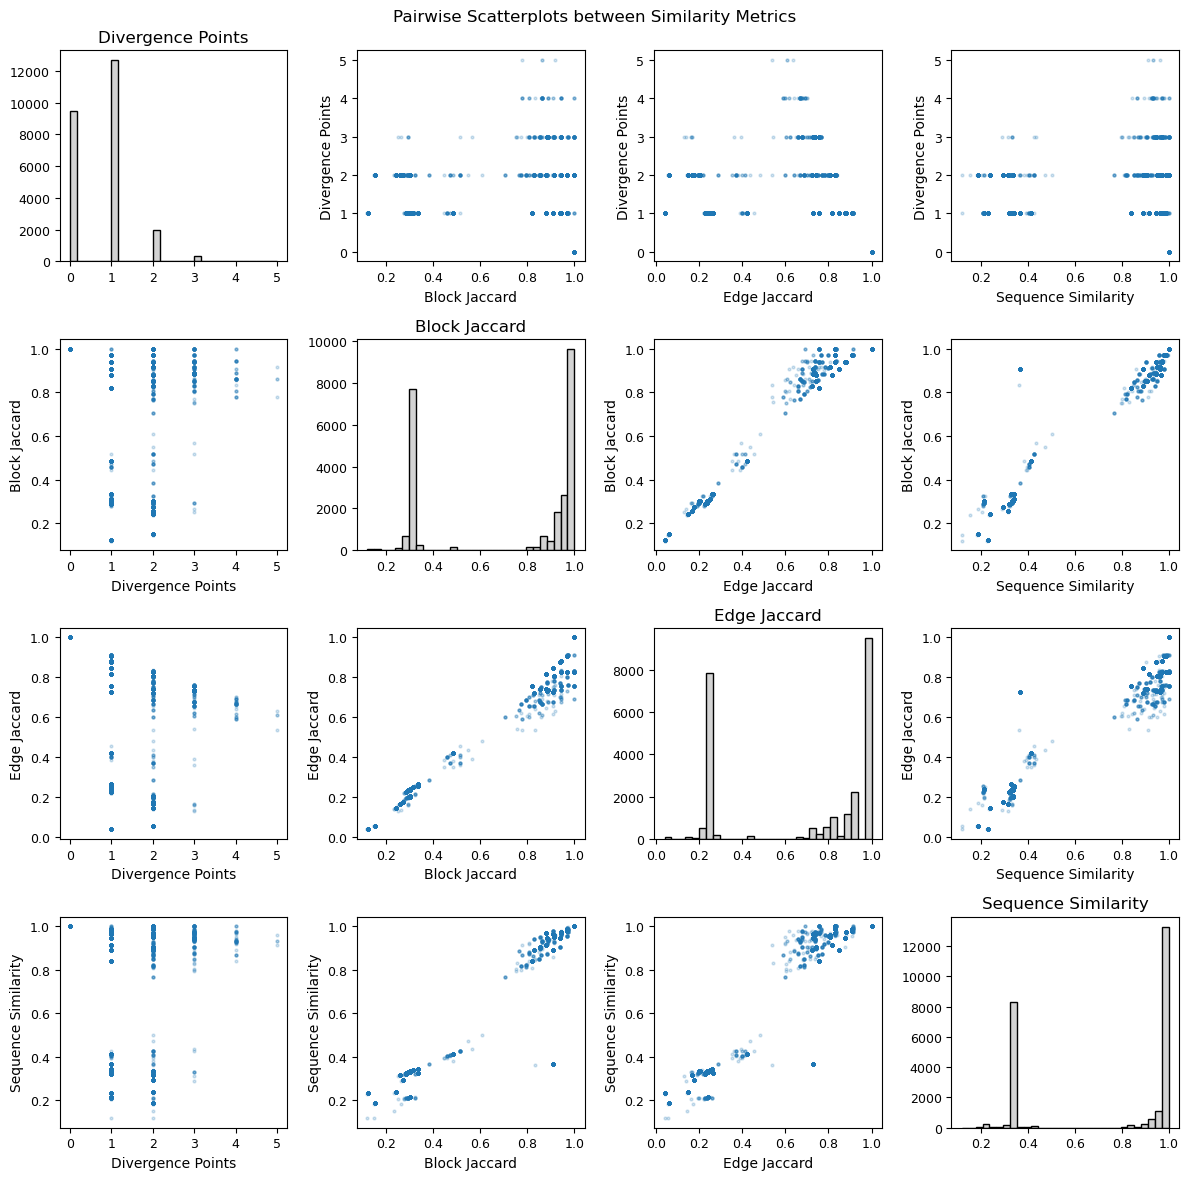

In [14]:
def plot_similarity_scatter(matrices, labels=None, figsize=(10, 10)):
    """
    Plot pairwise scatterplots between multiple similarity matrices.
    
    Parameters
    ----------
    matrices : list of pd.DataFrame
        List of symmetric similarity matrices (same index and columns).
    labels : list of str, optional
        Labels for each matrix. If None, generic labels are used.
    figsize : tuple
        Figure size.
    """
    n = len(matrices)
    if labels is None:
        labels = [f"Metric {i+1}" for i in range(n)]

    ref_order = matrices[0].index
    matrices = [m.loc[ref_order, ref_order] for m in matrices]

    def flatten_upper(df):
        vals = df.values
        iu = np.triu_indices_from(vals, k=1)
        return vals[iu]

    flat_vals = [flatten_upper(m) for m in matrices]

    fig, axes = plt.subplots(n, n, figsize=figsize)

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                # Diagonal: show histogram and label
                ax.hist(flat_vals[i], bins=30, color='lightgray', edgecolor='black')
                ax.set_title(labels[i], fontsize=12)
            else:
                ax.scatter(flat_vals[j], flat_vals[i], s=4, alpha=0.2)
                ax.set_xlabel(labels[j], fontsize=10)
                ax.set_ylabel(labels[i], fontsize=10)

            # Make ticks smaller but visible
            ax.tick_params(axis='both', which='major', labelsize=9)

    fig.suptitle("Pairwise Scatterplots between Similarity Metrics", fontsize=12)
    fig.tight_layout()
    plt.show()

plot_similarity_scatter([divergence_points_mat, jaccard_blocks_df, jaccard_edges_df, jaccard_sequences_df], labels=["Divergence Points", "Block Jaccard", "Edge Jaccard", "Sequence Similarity"], figsize=(12,12))

## Pipeline for one junction

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analyis/helpers.py:5: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



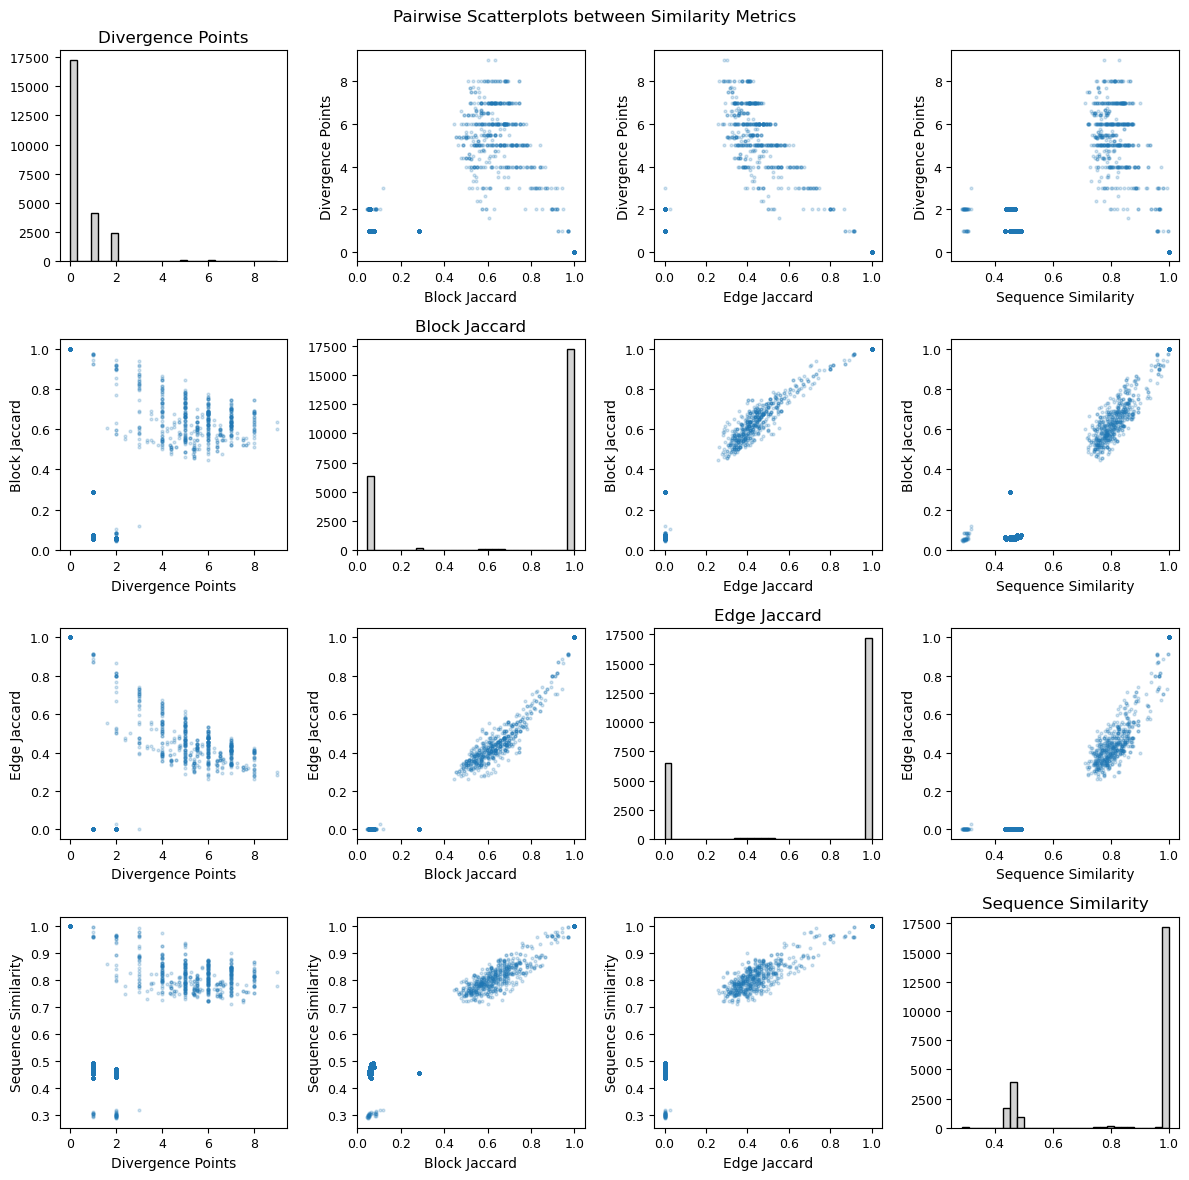

In [15]:
example_junction = "ATPWUNKKID_f__KKPYPKGMXA_f"
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")
example_pangraph.to_blockstats_df()

sequence_comparison_df = example_pangraph.pairwise_accessory_genome_comparison()
jaccard_sequences_df, diff, shared = compare_sequences_by_shared_proportion(sequence_comparison_df, order = "hierarchical")
plot_heatmap_hover(jaccard_sequences_df, diff, shared, show_tick_labels=False, similarity_measure="shared_proportion")

jaccard_blocks_df, diff, shared = calculate_block_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_blocks_df, diff, shared, show_tick_labels=False, similarity_measure="shared_blocks")

jaccard_edges_df, diff, shared = calculate_edge_ji_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(jaccard_edges_df, diff, shared, show_tick_labels=False, similarity_measure="shared_edges")

divergence_points_mat = calculate_divergence_matrix(example_pangraph, order="hierarchical")
plot_heatmap_hover(divergence_points_mat, show_tick_labels=False, similarity_measure="divergence_points")

plot_similarity_scatter([divergence_points_mat, jaccard_blocks_df, jaccard_edges_df, jaccard_sequences_df], labels=["Divergence Points", "Block Jaccard", "Edge Jaccard", "Sequence Similarity"], figsize=(12,12))

## Pypangraph playground

In [16]:
example_pangraph.to_blockcount_df()
example_pangraph.paths.keys()

['NZ_CP023844.1',
 'NZ_CP124511.1',
 'NZ_OW849064.1',
 'NZ_CP014497.1',
 'NZ_CP124372.1',
 'NZ_CP107114.1',
 'NZ_OX637964.1',
 'NZ_CP124355.1',
 'NZ_CP019008.1',
 'NZ_CP133923.1',
 'NZ_CP013658.1',
 'NZ_CP124467.1',
 'NZ_CP107155.1',
 'NZ_CP018991.1',
 'NZ_CP098219.1',
 'NZ_OW968277.1',
 'NZ_CP032265.1',
 'NZ_CP080120.1',
 'NZ_CP124392.1',
 'NZ_CP124481.1',
 'NZ_CP124424.1',
 'NZ_CP021454.1',
 'NZ_LR890693.1',
 'NZ_CP124320.1',
 'NZ_CP124429.1',
 'NZ_CP124495.1',
 'NZ_CP069488.1',
 'NZ_CP107120.1',
 'NZ_CP013831.1',
 'NZ_AP018784.1',
 'NZ_CP097360.1',
 'NZ_CP107128.1',
 'NZ_CP021935.1',
 'NZ_CP035516.1',
 'NZ_CP023853.1',
 'NZ_CP124341.1',
 'NZ_CP018983.1',
 'NZ_CP082831.1',
 'NZ_CP029420.1',
 'NZ_AP022525.1',
 'NZ_CP104846.1',
 'NZ_CP124405.1',
 'NZ_CP095520.1',
 'NZ_CP035720.1',
 'NZ_CP124353.1',
 'NZ_CP102061.1',
 'NZ_CP015074.2',
 'NZ_CP104848.1',
 'NZ_CP059281.1',
 'NZ_CP103755.1',
 'NZ_CP124455.1',
 'NZ_CP097367.1',
 'NZ_CP107147.1',
 'NZ_AP022326.1',
 'NZ_CP107134.1',
 'NZ_LS999

In [17]:

aligner = Align.PairwiseAligner()


aligner.mode = 'global'
aligner.match_score = 1
aligner.mismatch_score = 0
alignments = aligner.align("GAACT", "GAT")
alignment = alignments[0]
alignments[0].sequences

for index in range(len(alignments)):
    print(alignments[index])
    print(alignments[index].score)

# block duplication, we want block with less divergence points

target            0 GAACT 5
                  0 ||--| 5
query             0 GA--T 3

3.0
target            0 GAACT 5
                  0 |-|-| 5
query             0 G-A-T 3

3.0


In [18]:
aln1, aln2 = alignments[0]
aln2

'GA--T'

GAACT
||--|
GA--T

Beispiel für Sequenzen, die je nach scoring system 2 oder eine divergence sequenz haben

GAACT
|-|-|
G-A-T